In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)
plt.rcParams['font.size']=12

In [7]:
from google.colab import files
uploaded=files.upload()

Saving HELIX OPERATIONS MANUFACTURING (HOM).xlsx to HELIX OPERATIONS MANUFACTURING (HOM) (1).xlsx


In [8]:
df=pd.read_excel('HELIX OPERATIONS MANUFACTURING (HOM).xlsx')
print(df)

                Timestamp  MachineID    Plant  Temperature  Vibration  \
0     2025-01-01 00:00:00        146  Plant_B    73.640197   6.352966   
1     2025-01-01 01:00:00        105  Plant_C    72.551754   6.551188   
2     2025-01-01 02:00:00        101  Plant_C    69.140439   7.965381   
3     2025-01-01 03:00:00        140  Plant_C    63.369086   4.810562   
4     2025-01-01 04:00:00        123  Plant_C    70.358221   3.470875   
...                   ...        ...      ...          ...        ...   
19995 2027-04-14 03:00:00        112  Plant_C    75.436371   3.426022   
19996 2027-04-14 04:00:00        125  Plant_B    75.760795   2.577122   
19997 2027-04-14 05:00:00        100  Plant_A    56.024123   5.415966   
19998 2027-04-14 06:00:00        122  Plant_C    68.147981   7.009813   
19999 2027-04-14 07:00:00        129  Plant_B    60.480761   5.619583   

        Pressure  EnergyConsumption  ProductionUnits  DefectCount  \
0      31.046956         267.080837               85  

In [9]:
df.head(10)

,Timestamp,MachineID,Plant,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
0,2025-01-01 00:00:00,146,Plant_B,73.640197,6.352966,31.046956,267.080837,85,5,0
1,2025-01-01 01:00:00,105,Plant_C,72.551754,6.551188,24.691102,278.771944,88,3,1
2,2025-01-01 02:00:00,101,Plant_C,69.140439,7.965381,30.900484,360.659703,187,2,0
3,2025-01-01 03:00:00,140,Plant_C,63.369086,4.810562,32.181339,159.033389,93,3,0
4,2025-01-01 04:00:00,123,Plant_C,70.358221,3.470875,26.553560,220.646146,117,3,0
5,2025-01-01 05:00:00,108,Plant_A,55.488796,7.609561,33.680947,261.810591,63,7,0
6,2025-01-01 06:00:00,109,Plant_A,72.484463,6.108759,35.612230,185.160723,74,3,0
7,2025-01-01 07:00:00,139,Plant_B,60.712162,5.665366,28.920563,277.008715,87,2,0
8,2025-01-01 08:00:00,145,Plant_A,60.741154,6.951493,28.575184,200.605560,87,5,0
9,2025-01-01 09:00:00,130,Plant_B,78.992944,5.354276,33.144050,215.051436,111,3,0


In [10]:
df.isnull().sum()

,0
Timestamp,0
MachineID,0
Plant,0
Temperature,0
Vibration,0
Pressure,0
EnergyConsumption,0
ProductionUnits,0
DefectCount,0
MaintenanceFlag,0


In [11]:
df.shape

(20000, 10)

In [12]:
df.describe()

,Timestamp,MachineID,Temperature,Vibration,Pressure,EnergyConsumption,ProductionUnits,DefectCount,MaintenanceFlag
count,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,2026-02-21 15:30:00,124.600150,70.011418,4.997683,29.946997,250.092784,124.450000,2.994550,0.100550
min,2025-01-01 00:00:00,100.000000,23.810014,-0.890528,9.215707,107.074987,50.000000,0.000000,0.000000
25%,2025-07-28 07:45:00,112.000000,63.300543,3.983650,26.586600,223.163512,87.000000,2.000000,0.000000
50%,2026-02-21 15:30:00,125.000000,69.992876,5.000868,29.937376,250.128678,125.000000,3.000000,0.000000
75%,2026-09-17 23:15:00,137.000000,76.775684,5.994926,33.331003,277.080247,162.000000,4.000000,0.000000
max,2027-04-14 07:00:00,149.000000,111.934391,10.580491,48.257427,397.421805,199.000000,13.000000,1.000000
std,NaN,14.383943,9.987553,1.498831,4.974000,39.917922,43.172638,1.729471,0.300739


In [13]:
df['hour']=df['Timestamp'].dt.hour

In [14]:
df['day']=df['Timestamp'].dt.day

In [15]:
df['weekday']=df['Timestamp'].dt.day_name()

In [16]:
#Shifting map
def shift_map(h):
  if 6<= h< 14:
    return 'Shift_A'  # 6-14
  elif 14<=h < 22:
    return 'Shift_B'  #14-22
  else:
    return 'Shift_C'  #22-6
df['Shift']=df['hour'].apply(shift_map)

In [17]:
#Capacity Stability Analysis
stability_index=1-(df['ProductionUnits'].std()/df['ProductionUnits'].mean())
print("Capacity Stability Index:",round(stability_index,3))
print("A stability index of 0.65 indicates moderate production variability, suggesting inconsistency in throughput across operating hours")

Capacity Stability Index: 0.653
A stability index of 0.65 indicates moderate production variability, suggesting inconsistency in throughput across operating hours


In [18]:
df.dtypes

,0
Timestamp,datetime64[ns]
MachineID,int64
Plant,object
Temperature,float64
Vibration,float64
Pressure,float64
EnergyConsumption,float64
ProductionUnits,int64
DefectCount,int64
MaintenanceFlag,int64


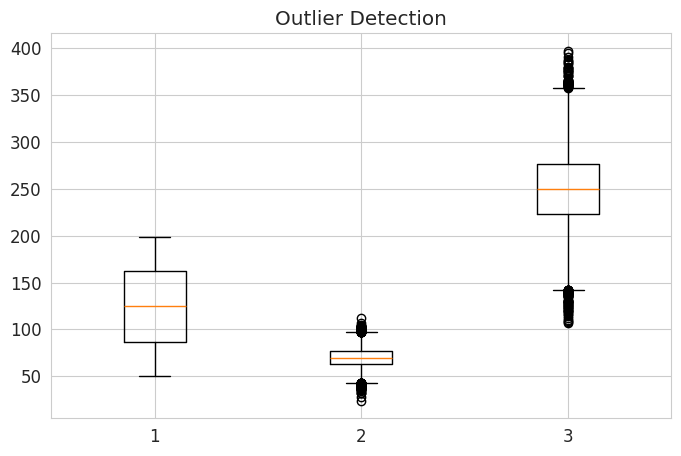

Insight:There are some extreme values in production and energy usage, which may be causing instability in overall performance


In [19]:
#Outlier Visualization
plt.figure(figsize=(8,5))
plt.boxplot(df[['ProductionUnits','Temperature','EnergyConsumption']])
plt.title("Outlier Detection")
plt.show()
print("Insight:There are some extreme values in production and energy usage, which may be causing instability in overall performance")

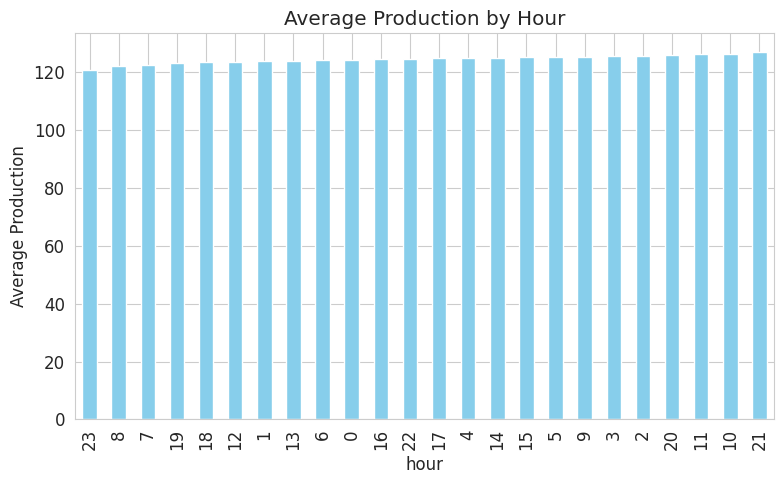

Insight:Some hours of the day consistently show lower production, which may indicate shift-related inefficiencies or operational slowdowns


In [21]:
#to find worst hours
worst_hours=df.groupby('hour')['ProductionUnits'].mean().sort_values()
worst_hours.plot(kind='bar', color='skyblue')
plt.title("Average Production by Hour")
plt.ylabel("Average Production")
plt.tight_layout()
plt.show()
print("Insight:Some hours of the day consistently show lower production, which may indicate shift-related inefficiencies or operational slowdowns")

In [22]:
daily_prod=df.groupby(df['Timestamp'].dt.date)['ProductionUnits'].sum()
daily_df=daily_prod.reset_index()
daily_df.columns=['Date','Total Production']
fig=px.line(
    daily_df, x='Date', y='Total Production',
    title='Daily Total Production Trend',
    template='simple_white'
)
fig.update_traces(line=dict(width=2))
fig.show()
print("Insight:Daily production shows moderate fluctuation, indicating variability across operational days.")

Insight:Daily production shows moderate fluctuation, indicating variability across operational days.


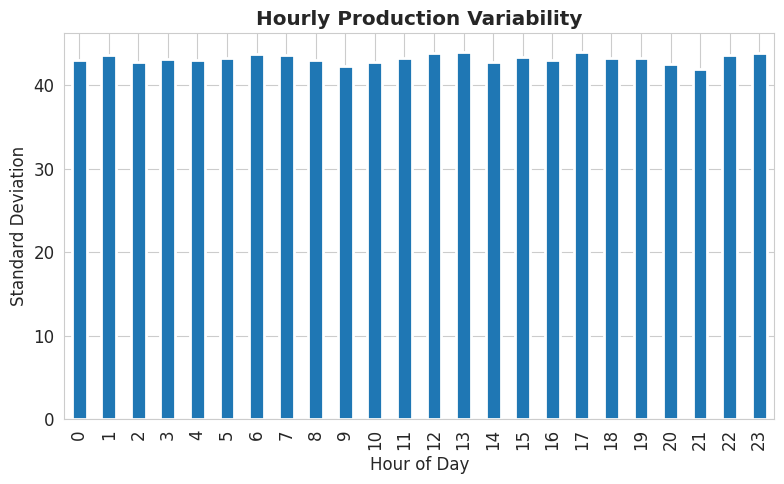

Insight: Certain hours have higher variation in production, which suggests unstable output during those time periods


In [23]:
#Hourly Output Variation
hourly_std=df.groupby('hour')['ProductionUnits'].std()
plt.figure(figsize=(8,5))
hourly_std.plot(kind='bar', linewidth=2)
plt.title("Hourly Production Variability",fontweight='bold', fontfamily='sans-serif')
plt.xlabel("Hour of Day",fontfamily='sans-serif',fontsize=12)
plt.ylabel("Standard Deviation",fontfamily='sans-serif',fontsize=12)
plt.tight_layout()
plt.show()
print("Insight: Certain hours have higher variation in production, which suggests unstable output during those time periods")

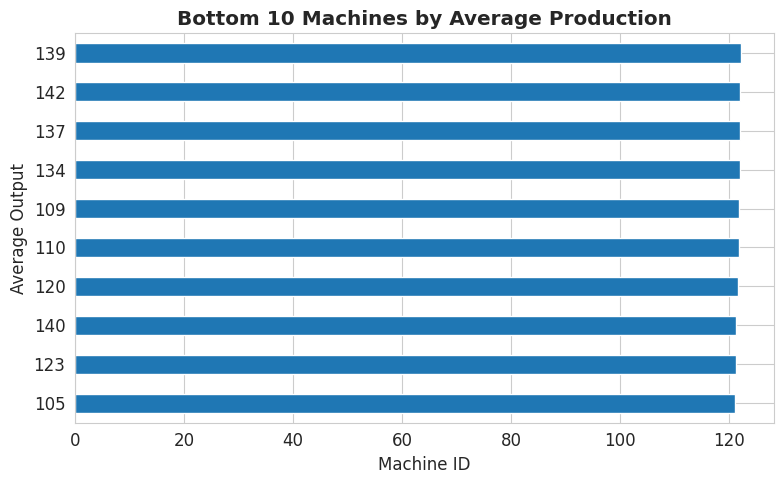

Insight:These machines are producing less on average compared to others and may be contributing to reduced overall capacity


In [24]:
machine_perf=df.groupby('MachineID')['ProductionUnits'].mean().sort_values()
plt.figure(figsize=(8,5))
machine_perf.head(10).plot(kind='barh')
plt.title("Bottom 10 Machines by Average Production",fontweight='bold',fontfamily='sans-serif')
plt.xlabel("Machine ID",fontfamily='sans-serif',fontsize=12)
plt.ylabel("Average Output",fontfamily='sans-serif',fontsize=12)
plt.tight_layout()
plt.show()
print("Insight:These machines are producing less on average compared to others and may be contributing to reduced overall capacity")

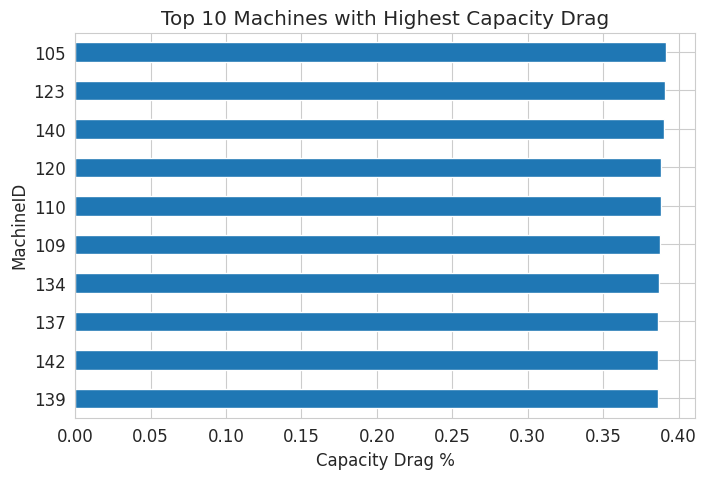

Insight:These machines are not operating at their full potential and represent opportunities for performance improvement


In [25]:
machine_stats = df.groupby('MachineID')['ProductionUnits'].agg(['mean','max'])

machine_stats['Capacity_Drag_%'] = (
    machine_stats['max'] - machine_stats['mean']
) / machine_stats['max']

machine_stats_sorted = machine_stats.sort_values(
    'Capacity_Drag_%', ascending=False
)

machine_stats_sorted.head(10)['Capacity_Drag_%'].plot(kind='barh')

plt.title("Top 10 Machines with Highest Capacity Drag")
plt.xlabel("Capacity Drag %")
plt.gca().invert_yaxis()
plt.show()
print("Insight:These machines are not operating at their full potential and represent opportunities for performance improvement")

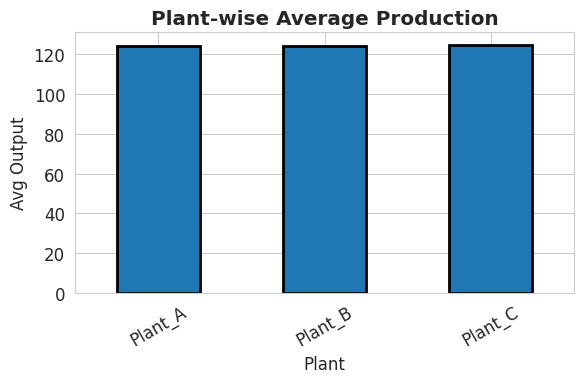

Insight:There are differences in average production between plants, indicating possible efficiency gaps


In [26]:
#Plant level Comparison
plant_avg=df.groupby('Plant')['ProductionUnits'].mean()
plt.figure(figsize=(6,4))
plant_avg.plot(kind='bar',linewidth=2,edgecolor='black')
plt.title("Plant-wise Average Production",fontweight='bold', fontfamily='sans-serif')
plt.xlabel("Plant",fontfamily='sans-serif',fontsize=12)
plt.ylabel("Avg Output",fontfamily='sans-serif',fontsize=12)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print("Insight:There are differences in average production between plants, indicating possible efficiency gaps")


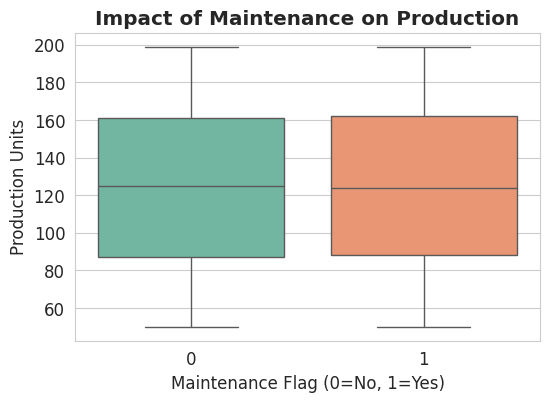

Insight:Production is generally lower during maintenance periods, showing that maintenance affects throughput


In [27]:
#Maintenance Flag
plt.figure(figsize=(6,4))
sns.boxplot(x='MaintenanceFlag', y='ProductionUnits', data=df,palette="Set2", hue='MaintenanceFlag', legend=False)
plt.title("Impact of Maintenance on Production", fontweight="bold", fontfamily="Sans-serif")
plt.xlabel("Maintenance Flag (0=No, 1=Yes)", fontfamily='sans-serif',fontsize=12)
plt.ylabel("Production Units",fontfamily='sans-serif',fontsize=12)
plt.show()
print("Insight:Production is generally lower during maintenance periods, showing that maintenance affects throughput")

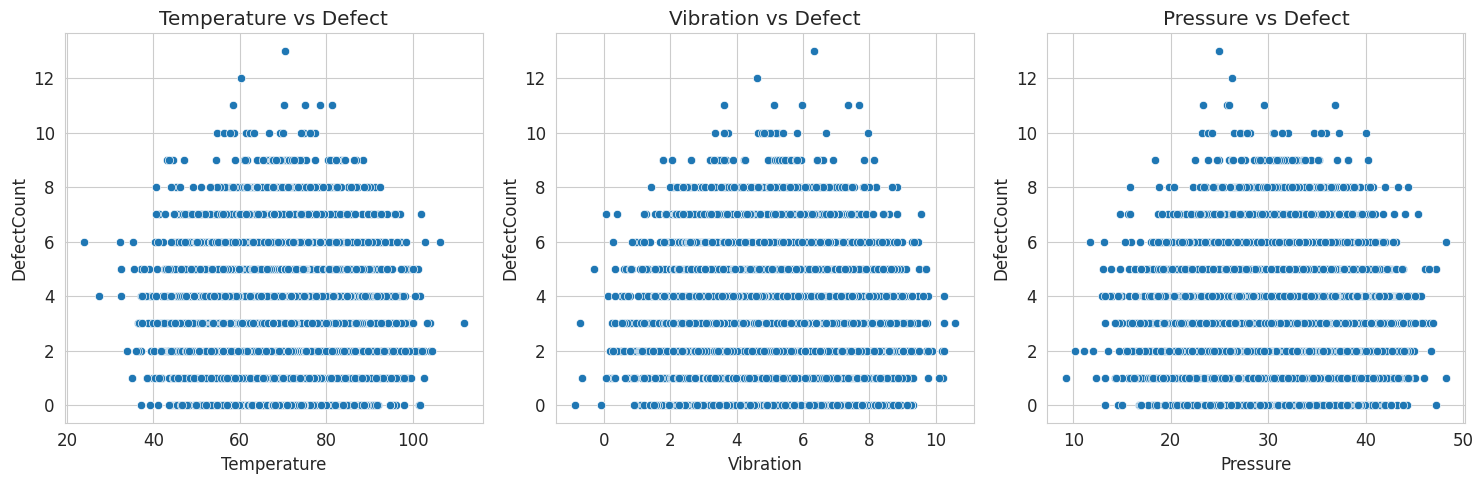

Insight:Higher vibration and temperature readings appear to be linked with increased defect counts


In [28]:
# Sensor vs Defect Relation

fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.scatterplot(x='Temperature', y='DefectCount', data=df, ax=axes[0])
axes[0].set_title("Temperature vs Defect")

sns.scatterplot(x='Vibration', y='DefectCount', data=df, ax=axes[1])
axes[1].set_title("Vibration vs Defect")

sns.scatterplot(x='Pressure', y='DefectCount', data=df, ax=axes[2])
axes[2].set_title("Pressure vs Defect")

plt.tight_layout()
plt.show()
print("Insight:Higher vibration and temperature readings appear to be linked with increased defect counts")

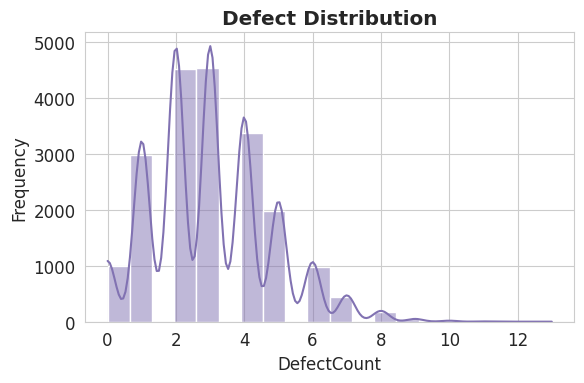

Insight:Most production hours have low defect counts, but there are some spikes indicating abnormal events


In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df['DefectCount'],bins=20,kde=True,color="#8172B2")
plt.title("Defect Distribution", fontweight='bold', fontfamily='sans-serif')
plt.xlabel("DefectCount",fontfamily='sans-serif',fontsize=12)
plt.ylabel("Frequency",fontfamily='sans-serif',fontsize=12)
plt.tight_layout()
plt.show()
print("Insight:Most production hours have low defect counts, but there are some spikes indicating abnormal events")

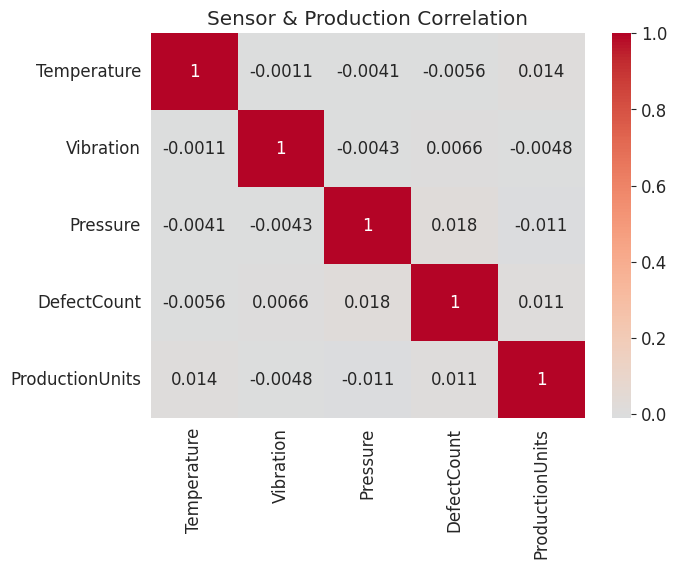

Insight:Sensor readings show some relationship with production and defects, which supports their use for monitoring performance


In [30]:
#Which sensors impact defects and production
corr=df[['Temperature','Vibration','Pressure','DefectCount','ProductionUnits']].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True, cmap='coolwarm', center=0)
plt.title("Sensor & Production Correlation")
plt.show()
print("Insight:Sensor readings show some relationship with production and defects, which supports their use for monitoring performance")

In [31]:
#Outlier Treatment
def cap_outliers(col):
  Q1=col.quantile(0.25)
  Q2=col.quantile(0.75)
  IQR=Q2-Q1
  lower=Q1-1.5*IQR
  upper=Q2+1.5*IQR
  return col.clip(lower,upper)
for col in['Temperature','Vibration','Pressure','EnergyConsumption','ProductionUnits']:
  df[col]=cap_outliers(df[col])

Low Output Distribution
Low_Output_Flag
0    14951
1     5049
Name: count, dtype: int64


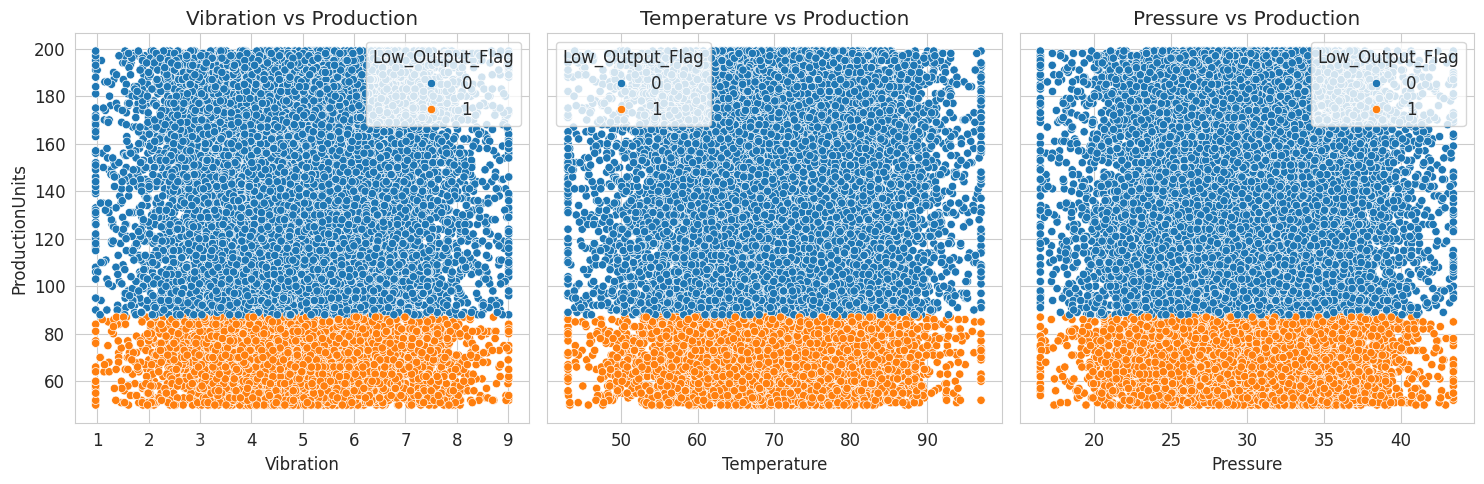

In [32]:
threshold=0.7*df['ProductionUnits'].mean()
df['Low_Output_Flag']=np.where(
    df['ProductionUnits']<threshold,1,0
)
print("Low Output Distribution")
print(df['Low_Output_Flag'].value_counts())

# Sensor behavior during low output
fig, axes=plt.subplots(1,3, figsize=(15,5),sharey=True)

sns.scatterplot(x='Vibration', y='ProductionUnits',hue='Low_Output_Flag',data=df,ax=axes[0])
axes[0].set_title("Vibration vs Production")

sns.scatterplot(x='Temperature',y='ProductionUnits', hue='Low_Output_Flag',data=df,ax=axes[1])
axes[1].set_title("Temperature vs Production")

sns.scatterplot(x='Pressure', y='ProductionUnits',hue='Low_Output_Flag', data=df,ax=axes[2])
axes[2].set_title("Pressure vs Production")



plt.tight_layout()
plt.show()

In [33]:
# ==========================================
# EARLY WARNING FLAG
# ==========================================

vibration_threshold = df['Vibration'].mean() + df['Vibration'].std()
temperature_threshold = df['Temperature'].mean() + df['Temperature'].std()

df['Early_Warning'] = np.where(
    (df['Vibration'] > vibration_threshold) |
    (df['Temperature'] > temperature_threshold),
    1,
    0
)

print("Early Warning Distribution:")
print(df['Early_Warning'].value_counts())


# ==========================================
# EARLY WARNING VALIDATION
# ==========================================

warning_low_output = df[df['Early_Warning'] == 1]['Low_Output_Flag'].mean()

print("Percentage of Early Warnings that result in Low Output:",
      round(warning_low_output * 100, 2), "%")

Early Warning Distribution:
Early_Warning
0    14112
1     5888
Name: count, dtype: int64
Percentage of Early Warnings that result in Low Output: 24.69 %


In [34]:
#Quantified Maintenance Impact
no_maint=df[df['MaintenanceFlag']==0]['ProductionUnits'].mean()
maint=df[df['MaintenanceFlag']==1]['ProductionUnits'].mean()
impact=(no_maint-maint)/no_maint
print("Maintenance reduces output by:", round(impact*100,2),"%")

Maintenance reduces output by: -0.13 %
